# Kolmogorov–Arnold geometry in shallow MLPs

Reproduction of the Jacobian rank analysis in **Freedman & Mulligan**, *Spontaneous
Kolmogorov-Arnold Geometry in Shallow MLPs*
([arXiv:2509.12326](https://arxiv.org/abs/2509.12326)), with an added comparison against the
untrained network.

**The paper's idea.** The Kolmogorov–Arnold representation theorem builds universal inner
functions whose local geometry leaves a characteristic structure, readable in the Jacobian of
the first-layer map. The authors show that this geometry emerges **spontaneously** when
training ordinary single-hidden-layer MLPs with GeLU activation, within a window of target
complexity they call the *Goldilocks* regime: at a middle point that avoids being so easy that the network needs no
structure or being hard that it fails to learn. It is the mirror image of KAN networks:
instead of imposing KA structure by design, one watches it arise on its own.



## 1. Setup

Fixed seeds for numpy and TensorFlow. The network has one hidden layer (`depth = 1`) and five widths are swept.

In [1]:
import numpy as np
import math
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import itertools

os.makedirs("output", exist_ok=True)


seed=1
tf.random.set_seed(seed)
np.random.seed(seed)

N_sample=1000
epochs=10_000

patience=50

n_dim=3

width=[4,8,16,32, 64]
depth=1

l_r=0.01
beta_1=0.9
beta_2=0.999

min_delta=1e-6

batch=250

## 2. Target function

$f(x) = \prod_i \sin(\pi x_i)$ on $x \in [-1,1]^3$: the *xor* function of Eq. (III.1) in the
paper. It is continuous and non-separable, and changes sign across every hyperplane
$x_i = 0$, which places it in the regime where the phenomenon appears.

In [2]:
def xor(x):
    """
     Continuous target f(x) = prod_i sin(pi * x_i), the 'xor' function of Eq. (III.1)
     in the paper. It flips sign whenever an odd number of coordinates is negative,
     hence the name, but it is not boolean.
    """
    f=np.prod(np.sin(math.pi*x),axis=-1)
    return f

w = tf.random.normal((1, n_dim))
b = tf.random.normal((1,))

## 3. Architecture and training

Single-hidden-layer MLP with **GeLU** activation and a linear output, as in the paper.
Initialisation uses $1/\sqrt{\text{fan-in}}$ standard deviations with an explicit seed, so
`build_model` called with the same arguments always returns **the same initial weights**,
which is what makes the trained-versus-untrained comparison meaningful.

In [3]:
def build_model(input_dim: int, width: int, depth: int, seed: int,
                  name: str = "net"):
    """
        Builds a feedforward neural network with the specified input dimension, width, depth, and random seed. 
        The model uses the GeLU activation function for hidden layers and a linear activation for the output layer.
    """
    init_A = tf.keras.initializers.RandomNormal(
        mean=0.0, stddev=1.0 / np.sqrt(input_dim), seed=seed)
    init_B = tf.keras.initializers.RandomNormal(
        mean=0.0, stddev=1.0 / np.sqrt(width), seed=seed)

    inp = tf.keras.Input(shape=(input_dim,))
    x   = inp
    for _ in range(depth):
        x = tf.keras.layers.Dense(
            width, activation="gelu",
            kernel_initializer=init_A,
            bias_initializer='zeros'
        )(x)
    out = tf.keras.layers.Dense(1,activation="linear", kernel_initializer=init_B,
                                bias_initializer='zeros')(x)
    return tf.keras.Model(inp, out, name=name)

def r_squared(y_true, y_pred):
    """
        Computes the R-squared value (coefficient of determination), a statistical measure of how well the predictions approximate the true values.
    """
    ss_res = np.sum((y_true - y_pred.flatten())**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res / ss_tot

def train_and_eval(input_dim, w, depth, seed, name, x, y):
    """
        Trains the neural network model on the provided input data (x) and target data (y), and evaluates its performance using R-squared.
    """
    model = build_model(input_dim, w, depth, seed, name)
    opt = tf.keras.optimizers.Adam(learning_rate=l_r, beta_1=beta_1, beta_2=beta_2)
    model.compile(optimizer=opt, loss='mse')
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='loss', min_delta=min_delta, patience=patience, restore_best_weights=True
    )
    model.fit(x, y, batch_size=batch, epochs=epochs,
               verbose=0, callbacks=[early_stop])
    y_pred = model.predict(x, verbose=0)
    return r_squared(y, y_pred), model  # keep model for Jacobian/minor analysis (Sec IV)

## 4. Jacobian and minors

`jacobian` computes the Jacobian of the hidden-layer map analytically. For GeLU,
$\sigma(z) = z\,\Phi(z)$, the derivative is $\sigma'(z) = \Phi(z) + z\,\phi(z)$, with $\Phi$
and $\phi$ the standard normal CDF and density.

`minors_size_k` builds the size-$k$ minor matrix of Eq. (IV.1), i.e. the absolute value of
the $k$-th exterior power: rows are indexed by $k$-subsets of hidden neurons, columns by
$k$-subsets of inputs. `mean_minor` averages over the columns.

In [4]:
def jacobian(model, X):
    """
        Computes the Jacobian matrix of the model's output with respect to its input for a batch of input data X.
        The Jacobian is calculated using the chain rule and the properties of the GeLU activation function.
    """
    hidden_layer = model.layers[1]          # first Dense layer = inner map
    A = hidden_layer.kernel.numpy()         # Coefficents of the linear map
    a = hidden_layer.bias.numpy()           # Biases of the linear map

    Z= X@A+a                                #Argumet for the activation function
    F = 0.5 * (1 + tf.math.erf(Z / np.sqrt(2)).numpy())   # standard normal CDF
    phi=1/np.sqrt(2*math.pi)*np.exp(-Z**2/2)

    sigma_prime = F + Z * phi  
    # Outer product per example: J[b, j, i] = sigma_prime[b, j] * A[i, j]
    J = sigma_prime[:, :, None] * A.T[None, :, :]   # shape (B, m, n)
    return J

def minors_size_k(J_batch, k):
    """
    Computes the size-k minor matrix J^(k), the absolute value of the k-th
    exterior power of the Jacobian, per Eq. (IV.1). Rows are indexed by
    k-subsets of hidden neurons {1..m}, columns by k-subsets of inputs {1..n}.
    Returns array of shape (batch, C(m,k), C(n,k)).
    """
    B, m, n = J_batch.shape
    row_idx = list(itertools.combinations(range(m), k)) #creates all combinations of tuples of k elements
    col_idx = list(itertools.combinations(range(n), k))
    out = np.zeros((B, len(row_idx), len(col_idx)))
    for bi in range(B):
        for ri, rows in enumerate(row_idx):
            for ci, cols in enumerate(col_idx):
                sub = J_batch[bi][np.ix_(rows, cols)] #ix_... creates a 2d mesh picking the entries of the tuples of rows and columns 
                out[bi, ri, ci] = np.abs(np.linalg.det(sub))
    return out

def mean_minor(J_batch,k):
    """
    Computes the mean of the size-k minors of the Jacobian matrix J_batch, normalized by the number of combinations of inputs taken k at a time. 
    This provides a measure of the average size of the k-th exterior power of the Jacobian across the batch.
    """
    rho=1/math.comb(np.shape(J_batch)[2],k)*np.sum(minors_size_k(J_batch,k), axis=2)
    return rho

## 5. Thresholds and plotting

`zero_quartile` sets the thresholds below which a row counts as effectively zero. Two
choices worth making explicit:

- Thresholds are computed **on the untrained network**, which acts as the null model. Using
  the trained network as reference would make the comparison circular.
- The quantile level is scaled with $k$ (`q = k * q1`) because the number of rows grows as
  $\binom{m}{k}$ and the dynamic range of the minors widens with $k$; without that
  adjustment the three thresholds would pile up at the bottom of the distribution for large
  $k$.

`Zipf_helper` sorts the row means for the Zipf-style plot. 

In [5]:
def zero_quartile(row_means, k, q1):
    """
    Threshold below which a row is treated as effectively zero.

    Takes the row means ALREADY computed — mean_minor is the expensive operation in
    this notebook and must not be repeated. The quantile level is scaled with k
    because the dynamic range of the minors widens as k grows.
    """
    q = k * q1
    return np.quantile(row_means.flatten(), q)


def Zipf_helper(row_means):
    """
    Helper function to create Zipf-like plots of the sorted row means.
    """
    row_means=row_means.flatten()
    row_sort=np.sort(row_means)
    counting=np.linspace(1,np.shape(row_sort)[0],np.shape(row_sort)[0])
    return counting, row_sort

## 6. Data and learning versus width

$R^2$ of the trained network at each width, to locate the capacity at which it learns the function.

In [6]:
############################################################
#Data initialization
############################################################

data_rng = np.random.RandomState(0)
x_data    = data_rng.uniform(-1, 1, size=(N_sample, n_dim)).astype(np.float32)
y_data    = xor(x_data)




############################################################
#Analysis of learning with width of NN
############################################################

r2_list = []
for w in width:
    r2, model = train_and_eval(n_dim, w, depth, seed, "trainer",  x_data, y_data)
    r2_list.append(r2)
print("\n" + "=" * 20)
print(f"{'w':>4}  {'r2':>10} ")
print("=" * 20)
for i in range(len(width)):
    print(f"{width[i]:>4}  {r2_list[i]:>10.4f}")


   w          r2 
   4      0.5307
   8      0.8779
  16      0.9424
  32      0.9851
  64      0.9838


## 7. Rank structure: trained versus untrained

For the width-64 network, size-$k$ minors are computed for $k = 1, 2, 3$ and the sorted
curves of both networks are compared.

Both models come from `build_model` with the same seed, so they start from identical weights
and the only difference between the two curves is training.

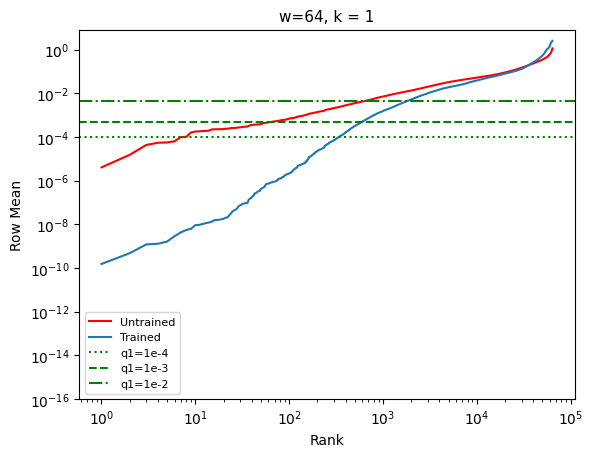

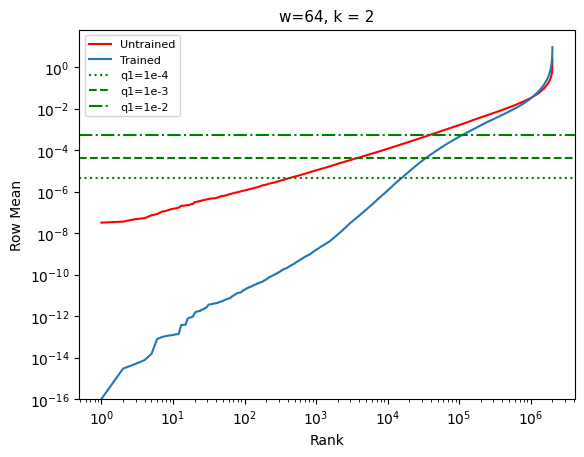

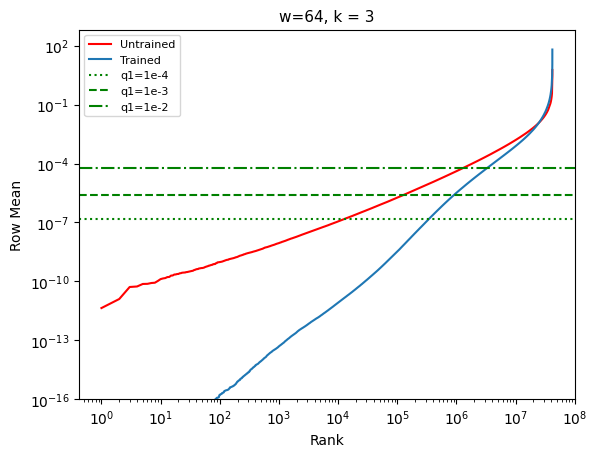

In [ ]:
############################################################
#Analysis of the rank of the Jacobian
############################################################

w=64
K=np.array([1,2,3])
q1=np.array([1e-4,1e-3,1e-2])
q1_style=['dotted', 'dashed', 'dashdot']
q1_labels=['q1=1e-4', 'q1=1e-3', 'q1=1e-2']

model=build_model(n_dim,w,depth,seed,"trainer")
r2, model_train=train_and_eval(n_dim, w, depth, seed, "trainer",  x_data, y_data)

J_int=jacobian(model, x_data)
J_train=jacobian(model_train,x_data)

for k in K:
    # mean_minor is the expensive call: compute once per network and reuse
    row_means_int   = mean_minor(J_int, k)
    row_means_train = mean_minor(J_train, k)
    Q1 = zero_quartile(row_means_int, k, q1)
    counting_int, row_sort_int= Zipf_helper(row_means_int)
    counting_train, row_sort_train= Zipf_helper(row_means_train)

    fig_k = plt.figure()
    plt.loglog(counting_int, row_sort_int, color="red", label="Untrained")
    plt.loglog(counting_train, row_sort_train, label="Trained")
    plt.ylim(bottom=1e-16)
    for i in range(np.shape(Q1)[0]):
        plt.axhline(y=Q1[i], color="green", linestyle=q1_style[i], label=q1_labels[i])
    plt.xlabel("Rank")
    plt.ylabel("Row Mean")
    plt.legend(fontsize=8, loc="best")
    plt.title(rf"w={w}, k = {k}", fontsize=11)
    plt.show()

   # ── Save figure ──────────────────────────────
    fig_k.savefig(f"output/jacobian_rank_w{w}_k{k}.pdf", bbox_inches="tight")

## 8. Results

**Learning versus width.** $R^2$ rises with width and approaches 1: the network does come to
represent the target function, which is the precondition for the question about its geometry
to mean anything.

**Collapse of the spectrum.** All three figures show a large gap between the trained and
untrained networks, and the gap **widens with $k$**. At $k = 1$ the curves separate clearly
at the low end but converge at the high end. At $k = 3$ the difference spans several orders
of magnitude: the trained network has an initial stretch falling below $10^{-16}$ while the
untrained one sits around $10^{-11}$.

The reading is that training annihilates a large number of directions in the exterior powers
of the Jacobian, whereas the untrained network spreads magnitude far more evenly across all
subsets. The low-rank structure is not in the initialisation: learning produces it. That the
effect sharpens with $k$ is what one expects if what emerges is a Kolmogorov–Arnold-type
geometry, in which the inner map aligns with a small number of directions.
